# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

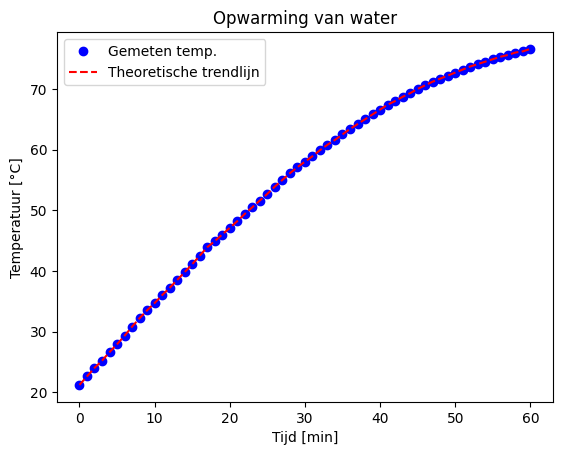

Energie voor opwarming: 109482.1 J
Energie voor verdamping: 40680.0 J
Totaal toegevoerde energie: 150162.1 J


In [10]:
import numpy as np 
import matplotlib.pyplot as plt


# Data inlezen
data = np.loadtxt("tempmetingen.csv", delimiter=";", skiprows=1)
tijd = data[:,0]            # in minuten
temp = data[:,1]            # in °C
m_beker = 820.8 / 1000      # kg
m_start = 1292.9 / 1000     # kg (beker + water start)
m_eind = 1274.9 / 1000      # kg (beker + water eind)
c_water = 4186              # J/(kg·K)
L_v = 2260*10**3            # J/kg, latente warmte

# Massa van water start en eind
m_water_start = m_start - m_beker
m_water_eind = m_eind - m_beker
m_water_verdamp = m_water_start - m_water_eind


deltaT = temp - temp[0]

Q_opwarming = m_water_start * c_water * deltaT  

# Plot van de metingen + theoretische lijn
plt.figure
plt.plot(tijd, temp, 'bo', label='Gemeten temp.')
plt.plot(tijd, temp[0] + Q_opwarming/(m_water_start*c_water), 'r--', label='Theoretische trendlijn')
plt.xlabel('Tijd [min]')
plt.ylabel('Temperatuur [°C]')
plt.title('Opwarming van water')
plt.legend()
plt.show()

# Energie nodig voor opwarming
Q_tot_opw = m_water_start * c_water * (temp[-1]-temp[0])

# Energie voor verdamping
Q_tot_verdamp = m_water_verdamp * L_v

# Totale toegevoerde energie
Q_tot = Q_tot_opw + Q_tot_verdamp

print(f"Energie voor opwarming: {Q_tot_opw:.1f} J")
print(f"Energie voor verdamping: {Q_tot_verdamp:.1f} J")
print(f"Totaal toegevoerde energie: {Q_tot:.1f} J")

De aannamens die bij deel 2 van de vraag behoren zijn: 
1. de soortelijke warmte (c) van water is 4186 J/(kg K)
2. de latente warmte is 2260*10^3 J/kg

De aanbevelingen voor een (nog) beter experiment: 
1. isolatie van beker om de warmte naar de omgeving te verminderen 
2. meet precies de hoeveelheid energie die wordt toegevoegd 
3. gebruik een roermachine om zo de temperatuur in het water overal hetzelfde te houden 